La función de distribución radial, $g(r)$, caracteriza la estructura geométrica local de un sistema de partículas. En un espacio bidimensional (2D), describe la probabilidad de encontrar una partícula a una distancia $r$ respecto a otra tomada como referencia, normalizada con la densidad promedio del sistema ($\rho$). Esta probabilidad será nula para cualquier distancia menor que dos veces el radio, porque las partículas no pueden solaparse. El primer pico estará precisamente en $r=2R$ (partículas en contacto directo). Le seguirán otros picos que se irán atenuando con la distancia.

El número de partículas $dN$ contenidas en un anillo de radio $r$ y espesor diferencial $dr$ en torno a una partícula central se define mediante la expresión:

$$dN = \rho \cdot g(r) \cdot 2\pi r \, dr$$

Despejando la función:

$$g(r) = \frac{dN}{2\pi r \rho dr}$$

Las aplicaciones principales de la $g(r)$ consisten en determinar la fase del sistema (gas, líquido o sólido) mediante su orden geométrico local, calcular propiedades termodinámicas globales como la presión o la energía interna a través de ecuaciones integrales, y validar simulaciones de Dinámica Molecular al comparar los resultados del algoritmo con datos experimentales de difracción de rayos X o de neutrones.

El sistema físico analizado consiste en un conjunto de $N = 484$ discos duros bidimensionales (2D) e impenetrables confinados en una caja cuadrada. En la simulación, se toma el radio de los discos como unidad de longitud ($R = 1$). El estado global del sistema viene dado por su fracción de empaquetamiento ($\nu = 0.2$), que determina el grado de compresión espacial de los discos.A partir de $\nu$ y $N$, el lado real de la caja del sistema se establece mediante la relación $L = 2\sqrt{N}\sqrt{\frac{\pi}{4\nu}}\approx 87.2$.

El algoritmo que usaremos calcula la función de distribución radial a partir de las coordenadas del sistema. Para ello, primero determina el número total de discos y estima la longitud del lado de la caja restando las posiciones extremas (y teniendo en cuenta también el radio de los discos). Estos dos valores permiten deducir la densidad de la distribución. A continuación, el código calcula las distancias relativas entre todos los pares de partículas posibles operando con matrices. Con el fin de eliminar los efectos de borde y simular un espacio infinito, se asume que la caja principal está rodeada de copias exactas de sí misma. En el código, esto se implementa evaluando las separaciones en los ejes horizontal y vertical: si la distancia entre dos partículas supera la mitad de la caja, se le suma o resta la longitud total de esta, forzando así a tomar el camino más corto a través de los límites. Una vez ajustadas estas separaciones, se calcula la distancia real en línea recta mediante el teorema de Pitágoras y se filtran los datos para no contabilizar los pares por duplicado. Finalmente, las distancias válidas se agrupan en un histograma que cuenta cuántas partículas caen dentro de anillos concéntricos sucesivos. Para obtener la función final, este recuento se normaliza dividiéndolo entre el número de discos, la densidad y el área exacta de cada anillo.

El programa estima un tamaño real para la caja de $L \approx 87.05$, resultado que coincide con el cálculo teórico. Este valor da una densidad promedio del sistema de $\rho \approx 0.0639$. Al observar la gráfica de la función de distribución radial, se aprecia que esta adquiere un valor nulo para distancias menores a dos veces el radio, lo cual es el resultado esperado. Inmediatamente después, la gráfica presenta un primer pico pronunciado que indica la presencia de una primera capa de coordinación alrededor de la partícula de referencia. Tras unas oscilaciones, la función decae y se estabiliza rápidamente en torno al valor unitario. Este aplanamiento demuestra que no existe un orden a largo alcance entre los discos; es decir, la probabilidad de encontrar una partícula lejos de la de referencia se vuelve aleatoria y constante. Este resultado indica que los discos se comportan como un gas o un fluido de baja densidad, lo cual es perfectamente coherente con la baja fracción de empaquetamiento que hemos usado.

N=484
L=87.05
ρ=0.0639


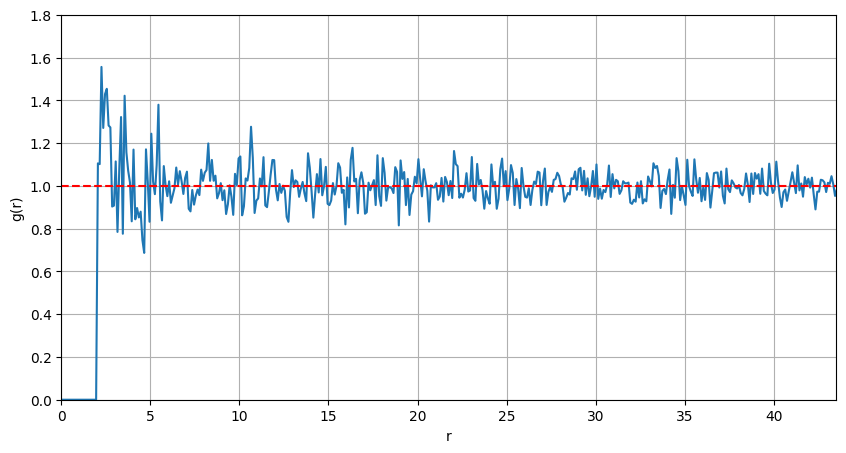

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nombre_archivo = 'xy5000.dat'

datos = pd.read_csv(nombre_archivo, sep=r'\s+', header=None, names=['x', 'y'])
posiciones = datos.to_numpy()

N = len(posiciones)

x = posiciones[:, 0]
y = posiciones[:, 1]

R = 1
L = (np.max(x) - np.min(x)) + 2 * R
rho = N / (L**2)

dx = x[:, np.newaxis] - x
dy = y[:, np.newaxis] - y

dx = dx - L * np.round(dx / L)
dy = dy - L * np.round(dy / L)

distancias_matriz = np.sqrt(dx**2 + dy**2)
distancias_validas = distancias_matriz[np.triu_indices(N, k=1)]

r_max = L / 2
dr = 0.1

bins = np.arange(0, r_max + dr, dr)
conteo, bordes = np.histogram(distancias_validas, bins=bins)

r = (bordes[:-1] + bordes[1:]) / 2
area_anillo = np.pi * (bordes[1:]**2 - bordes[:-1]**2)

g_r = (2 * conteo) / (N * rho * area_anillo)

print(f"N={N}")
print(f"L={L:.2f}")
print(f"ρ={rho:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(r, g_r)
plt.axhline(1, color='red', linestyle='--')
plt.xlabel('r')
plt.ylabel('g(r)')
plt.xlim(0, r_max)
plt.ylim(0, 1.8)
plt.grid(True)
plt.show()